In [1]:
%pip install networkx matplotlib pydot

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%load_ext autoreload
%autoreload 2

import cpg_trie_parser as cpg_parser

In [3]:
from pathlib import Path
import pydot
import networkx as nx

dot_path = Path("services/frontend/export.dot")

dot_text = dot_path.read_text(encoding="utf-8")
graphs = pydot.graph_from_dot_data(dot_text)

P = graphs[0]
P

In [4]:
G = nx.MultiDiGraph()

for node in P.get_nodes():
    name = node.get_name()
    if name in (None, "node", "graph", "edge"):
        continue
    nid = str(name).strip('"')
    attrs = {k: v for k, v in node.get_attributes().items()}
    G.add_node(nid, **attrs)

for edge in P.get_edges():
    src = str(edge.get_source()).strip('"')
    dst = str(edge.get_destination()).strip('"')
    attrs = {k: v for k, v in edge.get_attributes().items()}
    G.add_edge(src, dst, **attrs)

print(G.number_of_nodes(), G.number_of_edges())

30548 164385


In [5]:
from typing import List, Tuple
import csv

def extract_logs(dataset_path: str, service: str, start_time: int, end_time: int) -> List[Tuple[str, str]]:
    logs = []
    try:
        with open(dataset_path, 'r') as f:
            reader = csv.reader(f)
            next(reader, None)
            for row in reader:
                if len(row) < 3:
                    continue
                try:
                    timestamp   = int(float(row[0]))
                    log_service = row[1].strip()
                    message     = row[2].strip()
                    if log_service.lower() == service.lower() and start_time <= timestamp <= end_time:
                        bucket = f"{log_service}@{timestamp}"
                        logs.append((bucket, message))
                except (ValueError, IndexError):
                    continue
    except FileNotFoundError:
        print(f"ERROR: Dataset file not found: {dataset_path}")
    print(f"✓ Extracted {len(logs)} logs for {service} in time window")
    return logs

In [6]:
dataset = "./dataset/re3ob_adservice_f3_1/logs.csv"
service = "frontend"
start = 1731903974
end = 1731903980
logs = extract_logs(dataset, service, start, end)

✓ Extracted 107 logs for frontend in time window


In [7]:
templates = cpg_parser.build_templates_from_cpg(G, max_ddg_depth=5)
root = cpg_parser.build_trie(templates)
cpg_parser.visualize_trie_matplotlib(root, output_path="trie.png")

[Trie] Saved matplotlib PNG -> trie.png


In [8]:
print("Templates:", len(templates))
for t in templates[:10]:
    print(f"[{t.call_node_id}] {t.method_name}() -> {t.raw_template} (static={t.static_count})")

Templates: 77
[30064771307] loadDeploymentDetails() -> failed to fetch the hostname for the pod <*> (static=8)
[30064771312] loadDeploymentDetails() -> failed to fetch the name of the cluster in which the pod is running <*> (static=14)
[30064771317] loadDeploymentDetails() -> failed to fetch the zone of the node where the pod is scheduled <*> (static=13)
[30064771328] loadDeploymentDetails() -> loaded deployment details <*> (static=3)
[30064772872] AddItem() -> method additem not implemented <*> (static=4)
[30064772874] GetCart() -> method getcart not implemented <*> (static=4)
[30064772876] EmptyCart() -> method emptycart not implemented <*> (static=4)
[30064772938] ListRecommendations() -> method listrecommendations not implemented <*> (static=4)
[30064772994] ListProducts() -> method listproducts not implemented <*> (static=4)
[30064772996] GetProduct() -> method getproduct not implemented <*> (static=4)


In [9]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import pandas as pd
from collections import defaultdict

# ── Шаг 1: маппинг логов с добавлением full_name ──────────────────────────
mappings = cpg_parser.map_logs(logs, root, templates, min_static=1)

# Быстрый lookup: method_node_id → full_name
node_to_fullname = {
    nid: data.get("FULL_NAME", "")
    for nid, data in G.nodes(data=True)
    if data.get("label") == '"METHOD"'
}

rows = []
for m in mappings:
    full_name = node_to_fullname.get(m.method_node_id, "—") if m.method_node_id else "—"
    rows.append({
        "bucket":         m.bucket,
        "matched":        "✓" if m.matched else "✗",
        "method_name":    m.method_name    if m.method_name    else "—",
        "full_name":      full_name,                              # ← новое поле
        "template":       m.template       if m.template       else "—",
        "score":          m.score,
        "call_node_id":   m.call_node_id   if m.call_node_id   else "—",
        "method_node_id": m.method_node_id if m.method_node_id else "—",
        "message":        m.message,
    })

df = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_rows", 200)
display(df)

,bucket,matched,method_name,full_name,template,score,call_node_id,method_node_id,message
0,frontend@1731903974,✓,ServeHTTP,"""main.logHandler.ServeHTTP""",request started <*>,2,30064774247,107374182800,request started
1,frontend@1731903974,✓,productHandler,"""main.frontendServer.productHandler""",serving product page <*>,3,30064773422,107374182767,serving product page
2,frontend@1731903974,✗,—,—,—,0,—,—,request complete
3,frontend@1731903974,✗,—,—,—,0,—,—,request complete
4,frontend@1731903974,✓,ServeHTTP,"""main.logHandler.ServeHTTP""",request started <*>,2,30064774247,107374182800,request started
5,frontend@1731903974,✓,addToCartHandler,"""main.frontendServer.addToCartHandler""",adding to cart <*>,3,30064773495,107374182768,adding to cart
6,frontend@1731903974,✗,—,—,—,0,—,—,request complete
7,frontend@1731903974,✓,ServeHTTP,"""main.logHandler.ServeHTTP""",request started <*>,2,30064774247,107374182800,request started
8,frontend@1731903974,✓,viewCartHandler,"""main.frontendServer.viewCartHandler""",view user cart <*>,3,30064773548,107374182770,view user cart
9,frontend@1731903974,✗,—,—,—,0,—,—,request complete


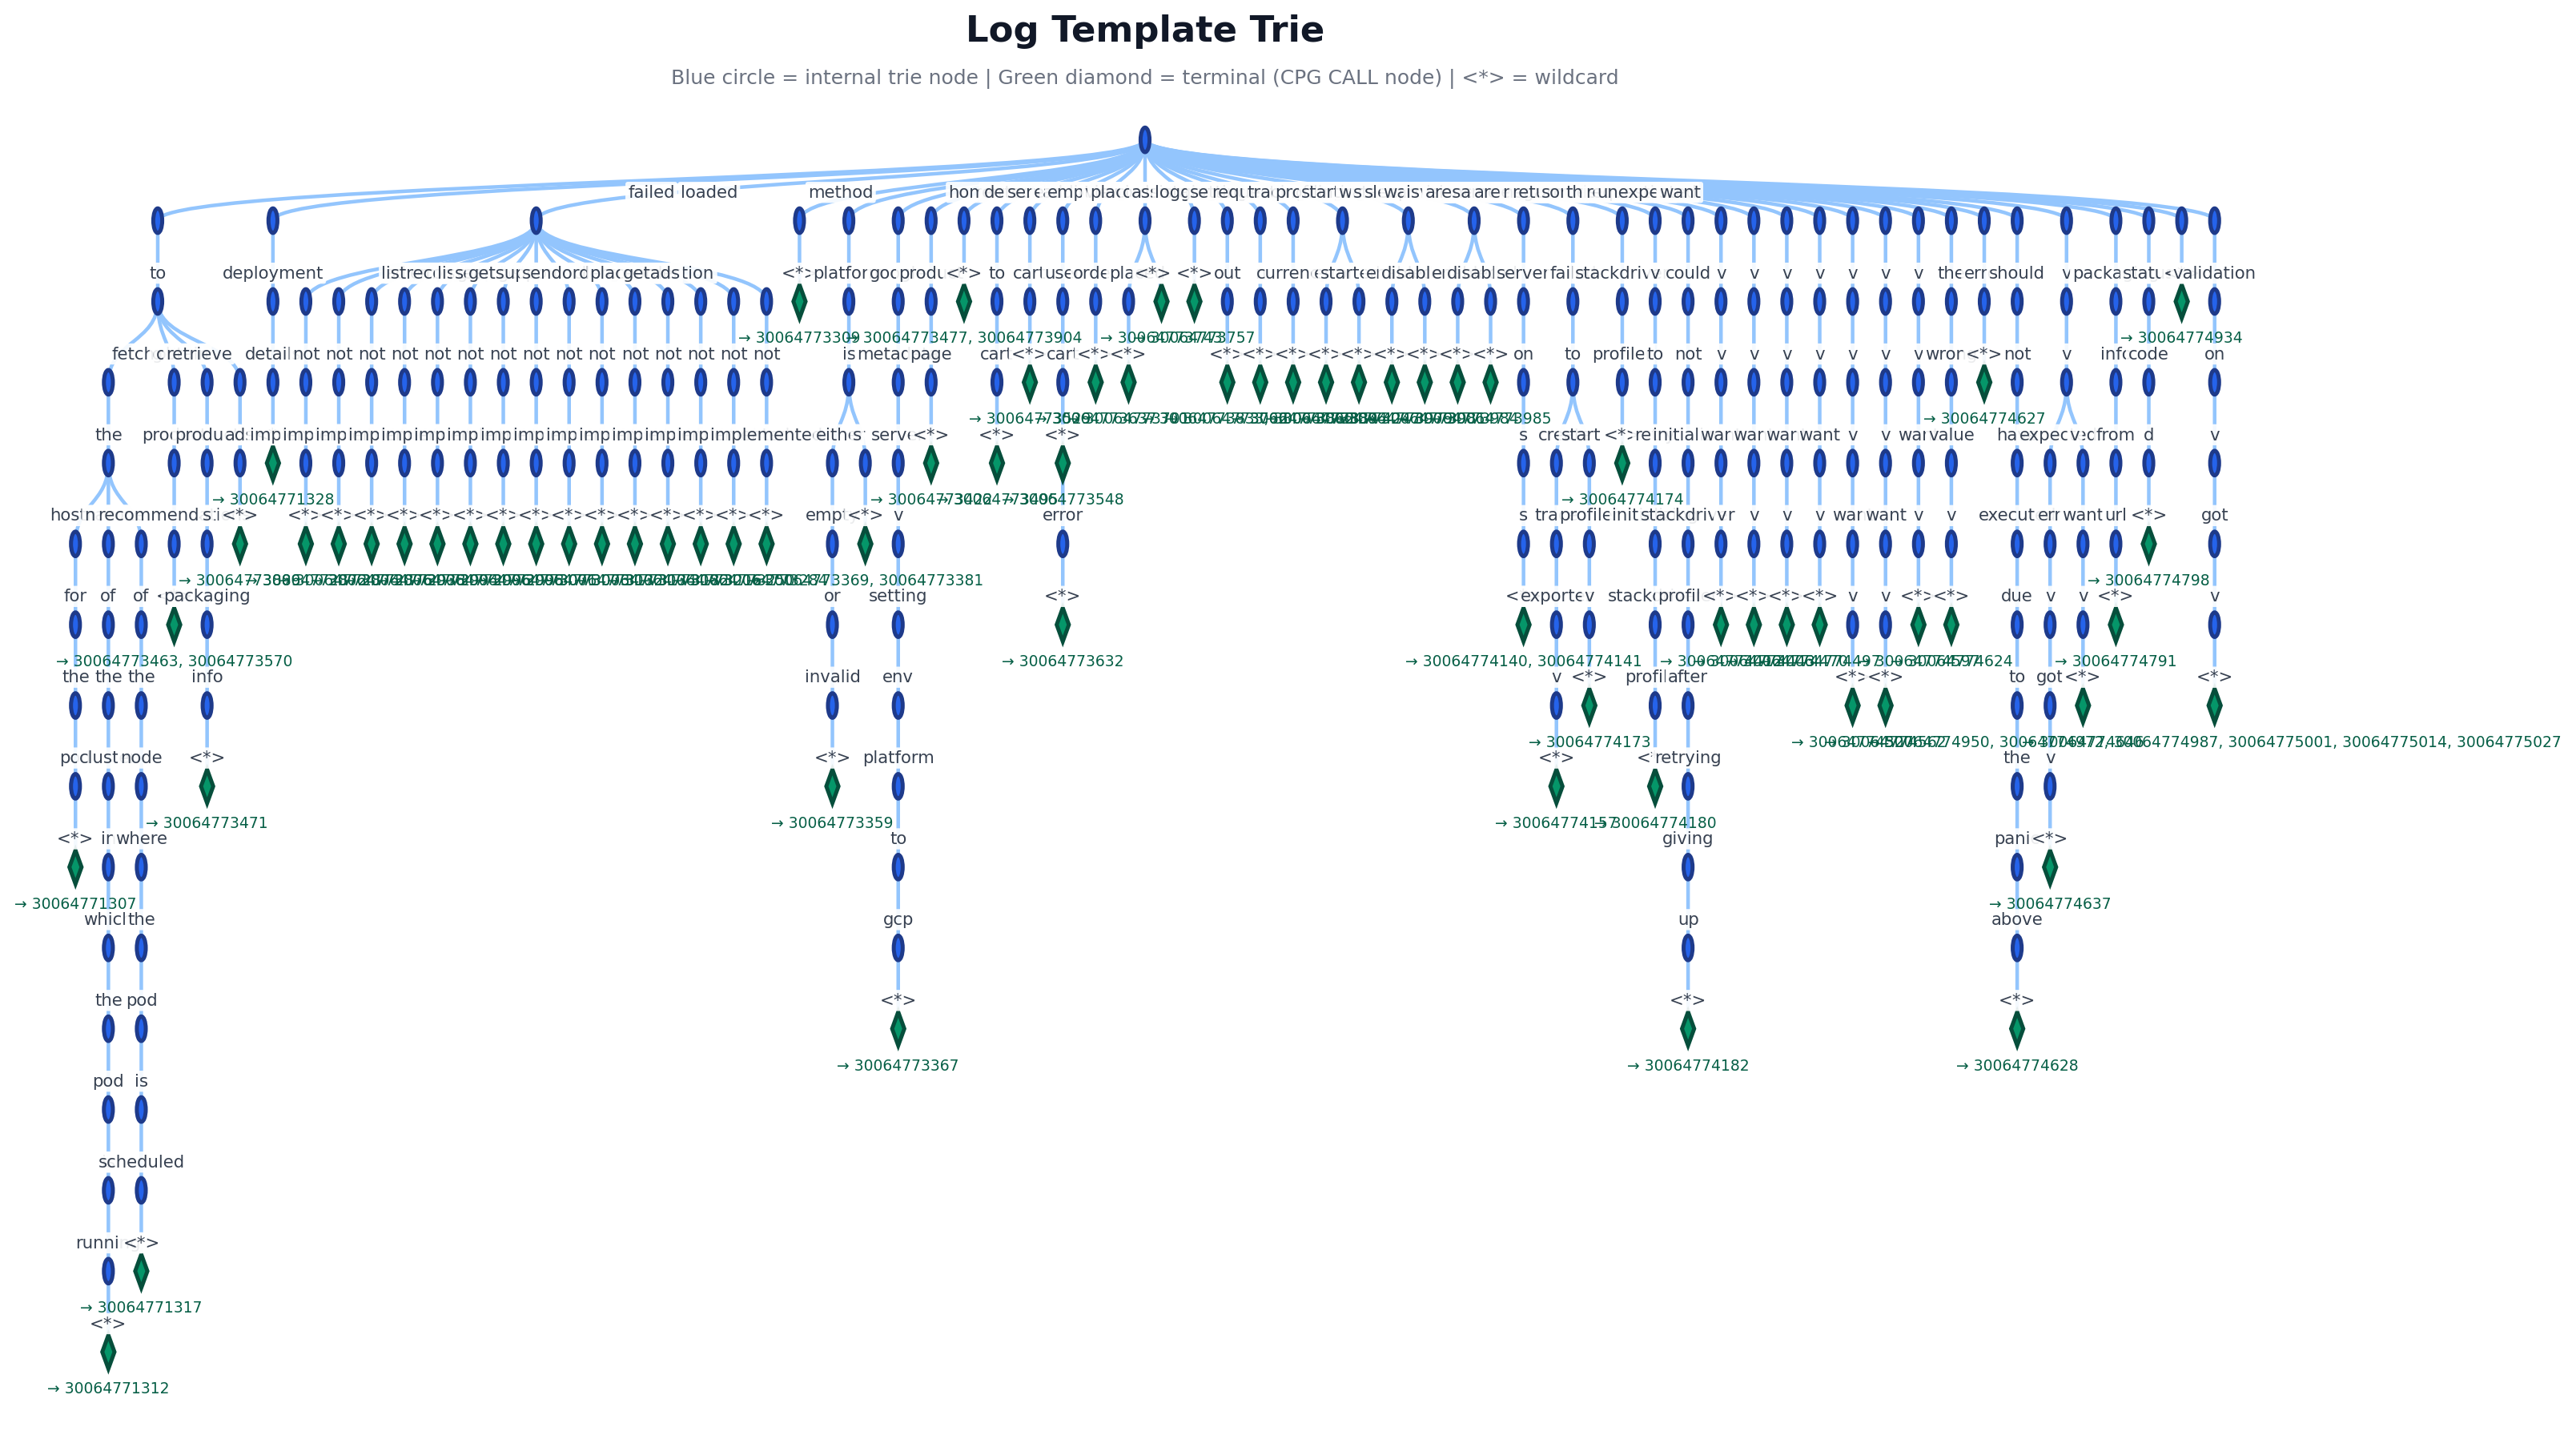

In [11]:
from IPython.display import Image, display
display(Image(filename="trie.png"))

In [12]:
def get_method_subgraphs_fixed(method_node_id):
    # 1. Все ноды по AST вниз
    method_nodes = set()
    queue = [method_node_id]
    while queue:
        cur = queue.pop()
        if cur in method_nodes: continue
        method_nodes.add(cur)
        for src, dst, data in G.out_edges(cur, data=True):
            lbl = data.get("label", "").strip('"')   # ← зачищаем кавычки
            if lbl == "AST":
                queue.append(dst)

    # 2. Собираем все рёбра внутри метода с зачисткой label
    cfg = nx.DiGraph()
    pdg = nx.DiGraph()
    
    for nid in method_nodes:
        d = G.nodes[nid]
        attrs = dict(
            label=d.get("label","").strip('"'),
            code=d.get("CODE","").strip('"')[:60],
            line=d.get("LINE_NUMBER","").strip('"'),
        )
        cfg.add_node(nid, **attrs)
        pdg.add_node(nid, **attrs)

    for src, dst, data in G.edges(data=True):
        if src not in method_nodes or dst not in method_nodes:
            continue
        lbl = data.get("label", "").strip('"')   # ← зачищаем
        if lbl == "CFG":
            cfg.add_edge(src, dst)
        elif lbl in ("CDG", "REACHING_DEF"):
            pdg.add_edge(src, dst, dep_type=lbl)

    return cfg, pdg, method_nodes

# Пересобираем method_graphs с исправленной функцией
method_graphs = {}
for m in mappings:
    if not m.matched or not m.method_node_id: continue
    if m.method_name in method_graphs: continue
    cfg, pdg, _ = get_method_subgraphs_fixed(m.method_node_id)
    method_graphs[m.method_name] = {
        "method_node_id": m.method_node_id,
        "cfg": cfg, "pdg": pdg,
    }
    print(f"{m.method_name:25s}  CFG: {cfg.number_of_edges():3d} рёбер  PDG: {pdg.number_of_edges():3d} рёбер")

ServeHTTP                  CFG:  75 рёбер  PDG: 204 рёбер
productHandler             CFG: 193 рёбер  PDG: 545 рёбер
addToCartHandler           CFG: 126 рёбер  PDG: 355 рёбер
viewCartHandler            CFG: 224 рёбер  PDG: 654 рёбер
chooseAd                   CFG:  26 рёбер  PDG:  85 рёбер
placeOrderHandler          CFG: 264 рёбер  PDG: 864 рёбер
homeHandler                CFG: 205 рёбер  PDG: 581 рёбер
setCurrencyHandler         CFG:  96 рёбер  PDG: 264 рёбер


C:\Users\Zevsoverlord\AppData\Local\Temp\ipykernel_18924\3900341223.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Zevsoverlord\AppData\Local\Temp\ipykernel_18924\3900341223.py:153: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.savefig(fname, dpi=150, bbox_inches="tight")
d:\ИТМО\аспирантура\cpg_rca\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


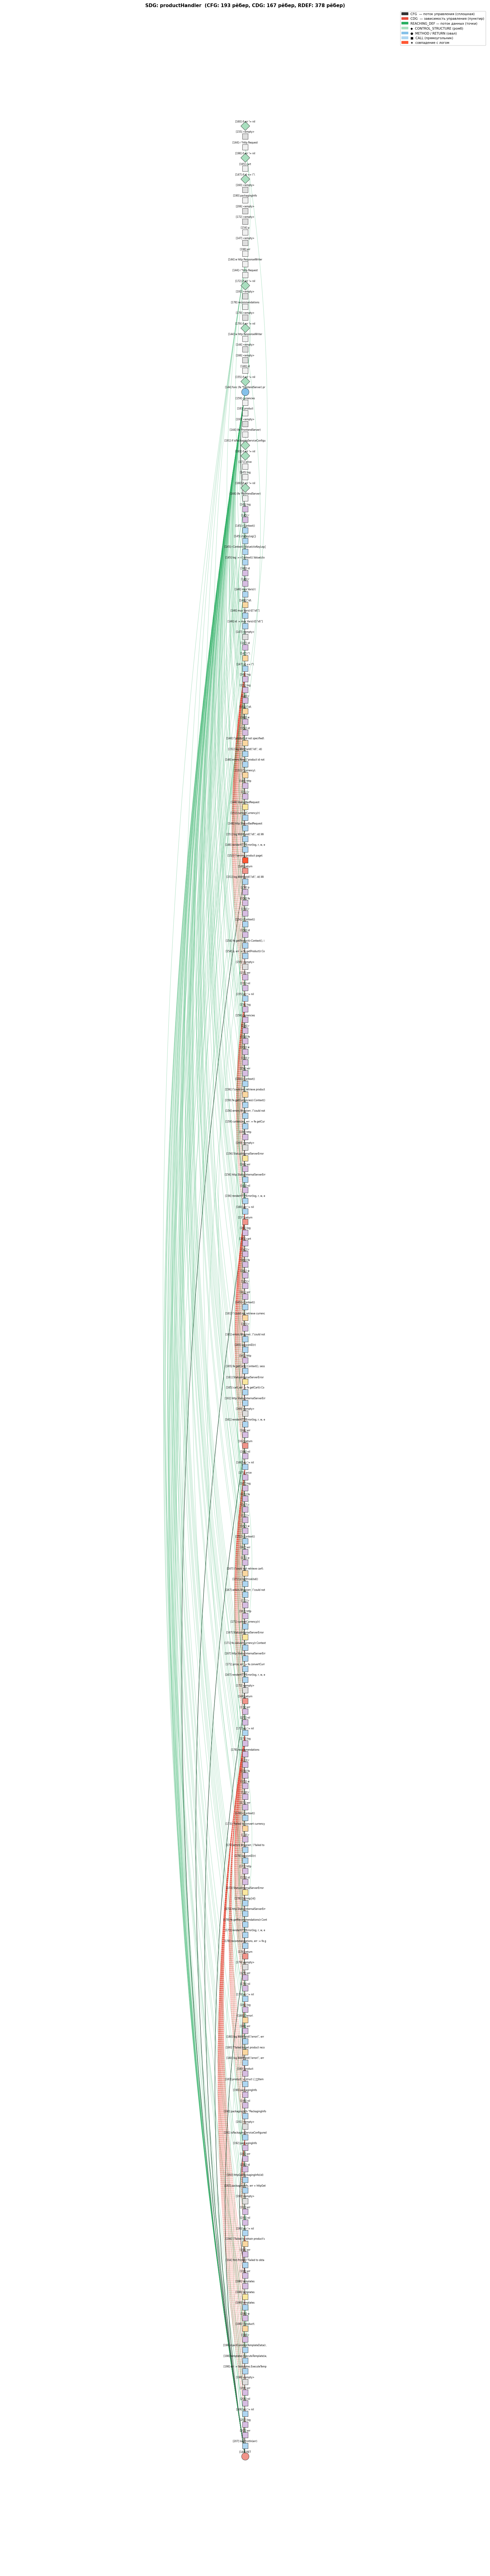

Сохранено: sdg_productHandler.png


In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import networkx as nx

def visualize_unified_cfg_pdg(method_name, method_graphs, highlight_messages=None):
    cfg = method_graphs[method_name]["cfg"]
    pdg = method_graphs[method_name]["pdg"]

    # Единый граф: все ноды + оба типа рёбер с атрибутом edge_kind
    unified = nx.MultiDiGraph()
    for nid, d in cfg.nodes(data=True):
        unified.add_node(nid, **d)
    for src, dst in cfg.edges():
        unified.add_edge(src, dst, edge_kind="CFG")
    for src, dst, d in pdg.edges(data=True):
        unified.add_edge(src, dst, edge_kind=d.get("dep_type", "CDG"))

    # Топологический порядок по CFG (от входа к выходу)
    try:
        order = list(nx.topological_sort(cfg))
    except nx.NetworkXUnfeasible:
        entry = next((n for n in cfg.nodes if cfg.in_degree(n) == 0), list(cfg.nodes)[0])
        order = list(nx.dfs_preorder_nodes(cfg, entry))

    # Позиции через graphviz dot (строго сверху вниз)
    try:
        pos = nx.nx_agraph.graphviz_layout(cfg, prog="dot")
    except Exception:
        # Fallback: по порядку топосортировки, x=0 для линейных, разброс для ветвлений
        pos = {nid: (0, -i * 55) for i, nid in enumerate(order)}

    # ── Форма ноды по типу (стандартная нотация) ─────────────────────────
    # CONTROL_STRUCTURE → ромб, METHOD/METHOD_RETURN → овал, остальные → прямоугольник
    # Реализуем через цвет + marker в scatter (matplotlib не поддерживает mixed shapes в draw)
    # Используем draw_networkx_nodes отдельно для каждой группы

    SHAPE_GROUPS = {
        "diamond": ["CONTROL_STRUCTURE"],          # ромб — условие
        "oval":    ["METHOD", "METHOD_RETURN"],    # овал — вход/выход
        "rect":    ["CALL", "RETURN", "BLOCK",
                    "IDENTIFIER", "LITERAL",
                    "FIELD_IDENTIFIER", "JUMP_TARGET"],
    }

    TYPE_COLORS = {
        "CALL":              "#AED6F1",   # голубой
        "RETURN":            "#F1948A",   # красный
        "CONTROL_STRUCTURE": "#A9DFBF",   # зелёный
        "LITERAL":           "#FAD7A0",   # оранжевый
        "IDENTIFIER":        "#D7BDE2",   # фиолетовый
        "BLOCK":             "#DEDEDE",   # серый
        "METHOD":            "#85C1E9",   # синий
        "METHOD_RETURN":     "#F1948A",   # красный
        "FIELD_IDENTIFIER":  "#F9E79F",   # жёлтый
        "JUMP_TARGET":       "#FDFEFE",   # белый
    }

    def get_group(lbl):
        for shape, types in SHAPE_GROUPS.items():
            if lbl in types: return shape
        return "rect"

    # Метки
    labels = {}
    for nid, d in unified.nodes(data=True):
        lbl  = d.get("label", "")
        code = d.get("code", "")[:28].replace("\n", " ")
        line = d.get("line", "")
        labels[nid] = f"[{line}] {code}" if code else f"[{line}] {lbl}"

    # Подсветка
    hit_nodes = set()
    if highlight_messages:
        for nid, d in unified.nodes(data=True):
            code = d.get("code", "").lower()
            if any(msg.lower() in code for msg in highlight_messages):
                hit_nodes.add(nid)

    h = max(12, len(unified.nodes) * 0.38)
    fig, ax = plt.subplots(figsize=(16, h))
    ax.set_title(f"SDG: {method_name}  "
                 f"(CFG: {cfg.number_of_edges()} рёбер, "
                 f"CDG: {sum(1 for _,_,d in pdg.edges(data=True) if d.get('dep_type')=='CDG')} рёбер, "
                 f"RDEF: {sum(1 for _,_,d in pdg.edges(data=True) if d.get('dep_type')=='REACHING_DEF')} рёбер)",
                 fontsize=11, fontweight="bold")

    all_nodes = list(unified.nodes())

    # ── Рисуем ноды по группам ────────────────────────────────────────────
    for nid in all_nodes:
        d    = unified.nodes[nid]
        lbl  = d.get("label", "")
        color = "#FF5733" if nid in hit_nodes else TYPE_COLORS.get(lbl, "#F0F0F0")
        shape = get_group(lbl)
        x, y  = pos.get(nid, (0, 0))

        if shape == "diamond":
            marker, size = "D", 220
        elif shape == "oval":
            marker, size = "o", 300
        else:
            marker, size = "s", 180

        ax.scatter(x, y, s=size, c=color, marker=marker,
                   zorder=3, edgecolors="#333", linewidths=0.7)

    # ── Метки нод ─────────────────────────────────────────────────────────
    for nid, (x, y) in pos.items():
        ax.annotate(labels.get(nid, ""), (x, y),
                    fontsize=5.5, ha="center", va="bottom",
                    xytext=(0, 8), textcoords="offset points", zorder=4)

    # ── Рёбра ─────────────────────────────────────────────────────────────
    EDGE_STYLES = {
        "CFG":          dict(color="#333333", lw=1.2, ls="-",  alpha=0.85),
        "CDG":          dict(color="#E74C3C", lw=0.9, ls="--", alpha=0.7),
        "REACHING_DEF": dict(color="#27AE60", lw=0.8, ls=":",  alpha=0.6),
    }

    for src, dst, d in unified.edges(data=True):
        if src not in pos or dst not in pos: continue
        kind  = d.get("edge_kind", "CFG")
        style = EDGE_STYLES.get(kind, EDGE_STYLES["CFG"])
        x1, y1 = pos[src]
        x2, y2 = pos[dst]
        ax.annotate("",
            xy=(x2, y2), xytext=(x1, y1),
            arrowprops=dict(
                arrowstyle="->" if kind == "CFG" else "->",
                color=style["color"],
                lw=style["lw"],
                linestyle=style["ls"],
                alpha=style["alpha"],
                connectionstyle="arc3,rad=0.08",
            ), zorder=2)

    # ── Легенда ───────────────────────────────────────────────────────────
    legend_handles = [
        mpatches.Patch(color="#333333",  label="CFG  — поток управления (сплошная)"),
        mpatches.Patch(color="#E74C3C",  label="CDG  — зависимость управления (пунктир)"),
        mpatches.Patch(color="#27AE60",  label="REACHING_DEF — поток данных (точки)"),
        mpatches.Patch(color="#A9DFBF",  label="◆  CONTROL_STRUCTURE (ромб)"),
        mpatches.Patch(color="#85C1E9",  label="●  METHOD / RETURN (овал)"),
        mpatches.Patch(color="#AED6F1",  label="■  CALL (прямоугольник)"),
        mpatches.Patch(color="#FF5733",  label="★  совпадение с логом"),
    ]
    ax.legend(handles=legend_handles, fontsize=7.5, loc="upper right",
              framealpha=0.95)
    ax.axis("off")
    plt.tight_layout()
    fname = f"sdg_{method_name}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Сохранено: {fname}")


# Запуск
visualize_unified_cfg_pdg(
    "productHandler",
    method_graphs,
    highlight_messages=["serving product page"]
)

In [20]:
from collections import defaultdict

# Паттерны псевдо-методов Joern — не реальные внешние вызовы
OPERATOR_PREFIXES = (
    "<operator>",
    "<operators>",
    "<init>",
    "<clinit>",
    "<lambda>",
    "<unresolvedNamespace>",
    "<unknownFullName>",
    "<ReturnType>",
)

def is_real_external(full_name: str) -> bool:
    """True если это настоящий внешний метод, а не Joern-псевдо."""
    fn = full_name.strip('"')
    for prefix in OPERATOR_PREFIXES:
        if fn.startswith(prefix):
            return False
    if not fn or fn == "<empty>":
        return False
    return True


def extract_external_callers(G):

    internal_methods = {
        nid: data for nid, data in G.nodes(data=True)
        if data.get("label") == '"METHOD"'
        and data.get("IS_EXTERNAL") != '"true"'
        and "<clinit>" not in data.get("NAME", "")
        and data.get("NAME", "").strip('"') not in ("init",)
    }

    # Только РЕАЛЬНЫЕ внешние методы (без операторов)
    external_methods = {
        nid: data for nid, data in G.nodes(data=True)
        if data.get("label") == '"METHOD"'
        and data.get("IS_EXTERNAL") == '"true"'
        and is_real_external(data.get("FULL_NAME", ""))
    }

    print(f"  Внутренних методов:          {len(internal_methods)}")
    print(f"  Реальных внешних методов:    {len(external_methods)}")

    # CALL-нода → метод-владелец
    call_node_to_method = {}
    for nid in internal_methods:
        for _, dst, edata in G.out_edges(nid, data=True):
            if edata.get("label") == '"CONTAINS"':
                if G.nodes[dst].get("label") == '"CALL"':
                    call_node_to_method[dst] = nid

    print(f"  CALL-нод найдено:            {len(call_node_to_method)}")

    # internal_method → вызовы реальных внешних методов
    external_calls = defaultdict(list)

    for call_nid, owner_nid in call_node_to_method.items():
        for _, dst, edata in G.out_edges(call_nid, data=True):
            if edata.get("label") == '"CALL"' and dst in external_methods:
                external_calls[owner_nid].append((call_nid, dst))

    print(f"  Методов с реальными внешними вызовами: {len(external_calls)}")

    results = []
    for owner_nid, calls in external_calls.items():
        owner_data = internal_methods[owner_nid]

        # Группируем уникальные внешние методы (дедупликация)
        seen_ext = {}
        for call_nid, ext_nid in calls:
            if ext_nid not in seen_ext:
                ext_data  = external_methods[ext_nid]
                call_data = G.nodes[call_nid]
                seen_ext[ext_nid] = {
                    "ext_nid":   ext_nid,
                    "ext_name":  ext_data.get("FULL_NAME", "").strip('"'),
                    "call_code": call_data.get("code", "").strip('"'),
                    "call_line": call_data.get("line", "").strip('"'),
                }

        results.append({
            "nid":           owner_nid,
            "name":          owner_data.get("NAME", "").strip('"'),
            "full_name":     owner_data.get("FULL_NAME", "").strip('"'),
            "ext_call_cnt":  len(calls),          # всего вызовов
            "ext_uniq_cnt":  len(seen_ext),       # уникальных внешних методов
            "ext_calls":     list(seen_ext.values()),
        })

    results.sort(key=lambda x: -x["ext_uniq_cnt"])
    return results, internal_methods, external_methods


# ── Запуск ───────────────────────────────────────────────────────────────
ext_callers, internal_methods, external_methods = extract_external_callers(G)

print(f"\nМетоды с реальными внешними вызовами: {len(ext_callers)}")
print(f"\n{'rank':>4}  {'calls':>5}  {'uniq':>4}  {'name':35s}  внешние методы")
print(f"{'─'*4}  {'─'*5}  {'─'*4}  {'─'*35}  {'─'*55}")

for rank, m in enumerate(ext_callers, 1):
    print(f"{rank:>4}  {m['ext_call_cnt']:>5}  {m['ext_uniq_cnt']:>4}  {m['name']:35s}  {m['full_name'][:50]}")
    for c in m['ext_calls'][:4]:
        line = f"[{c['call_line']}]" if c['call_line'] else "   "
        print(f"{'':>4}  {'':>5}  {'':>4}    → {line} {c['ext_name'][:60]}")
    if m['ext_uniq_cnt'] > 4:
        print(f"{'':>4}  {'':>5}  {'':>4}    ... ещё {m['ext_uniq_cnt']-4} уникальных")

# Сохраняем как endpoint_entry_ids для CFG-визуализации
endpoint_entry_ids = {
    m["nid"]: {"name": m["name"], "full_name": m["full_name"]}
    for m in ext_callers
}
print(f"\nendpoint_entry_ids: {len(endpoint_entry_ids)} методов")

  Внутренних методов:          465
  Реальных внешних методов:    259
  CALL-нод найдено:            3747
  Методов с реальными внешними вызовами: 258

Методы с реальными внешними вызовами: 258

rank  calls  uniq  name                                 внешние методы
────  ─────  ────  ───────────────────────────────────  ───────────────────────────────────────────────────────
   1     50    25  placeOrderHandler                    main.frontendServer.placeOrderHandler
                     →     net/http.Request.Context.<ReturnType>.<unknown>.Value.<Retur
                     →     net/http.Request.Context.<ReturnType>.<unknown>.Value.<Retur
                     →     github.com/GoogleCloudPlatform/microservices-demo/src/fronte
                     →     net/http.Request.Context.<ReturnType>.<unknown>.Value
                     ... ещё 21 уникальных
   2     54    24  main                                 main.main
                     →     go.opentelemetry.io/otel.SetTextMapPropagator
 

In [21]:
def build_full_call_graph(G, internal_methods):
    """METHOD_A → METHOD_B через CONTAINS → CALL"""
    cg = nx.DiGraph()
    for nid in internal_methods:
        cg.add_node(nid, **internal_methods[nid])
    
    call_node_to_method = {}
    for nid in internal_methods:
        for _, dst, edata in G.out_edges(nid, data=True):
            if edata.get("label") == '"CONTAINS"':
                if G.nodes[dst].get("label") == '"CALL"':
                    call_node_to_method[dst] = nid

    for call_nid, owner in call_node_to_method.items():
        for _, dst, edata in G.out_edges(call_nid, data=True):
            if edata.get("label") == '"CALL"' and dst in internal_methods:
                cg.add_edge(owner, dst)

    return cg


def find_exits(cg, internal_methods):
    """
    Точки выхода из сервиса:
    - out_degree = 0 в call graph (листья — ничего не вызывают внутри)
    - ИЛИ вызывают только внешние методы
    """
    exits = {}
    for nid in cg.nodes():
        if cg.out_degree(nid) == 0:
            d = internal_methods[nid]
            exits[nid] = d.get("NAME","").strip('"')
    return exits


def trace_all_routes(cg, endpoint_entry_ids, internal_methods, max_depth=40):
    """
    Для каждого эндпоинта — все пути до выходов из сервиса.
    Возвращает dict: endpoint_name → list of paths
    """
    exits = find_exits(cg, internal_methods)

    def get_name(nid):
        d = internal_methods.get(nid, {})
        return d.get("NAME","").strip('"') or str(nid)

    all_routes = {}

    for entry_id, ep in endpoint_entry_ids.items():
        ep_name = ep["name"]
        paths_to_exits = []

        # DFS: ищем все простые пути от entry до каждого exit
        for exit_id in exits:
            if exit_id == entry_id:
                continue
            try:
                for path in nx.all_simple_paths(cg, entry_id, exit_id, cutoff=max_depth):
                    paths_to_exits.append(path)
            except (nx.NetworkXNoPath, nx.NodeNotFound):
                continue

        # Если нет путей до exit — берём все пути от entry (весь достижимый граф)
        if not paths_to_exits:
            try:
                reachable = list(nx.dfs_preorder_nodes(cg, entry_id))
                paths_to_exits = [reachable]
            except Exception:
                paths_to_exits = [[entry_id]]

        all_routes[ep_name] = {
            "entry_id": entry_id,
            "paths":    paths_to_exits,
        }

    return all_routes, exits


# ── Запуск ────────────────────────────────────────────────────────────────

# Пересобираем internal_methods и call graph
internal_methods = {
    nid: data for nid, data in G.nodes(data=True)
    if data.get("label") == '"METHOD"'
    and data.get("IS_EXTERNAL") != '"true"'
    and "<clinit>" not in data.get("NAME","")
    and data.get("NAME","").strip('"') not in ("init",)
}

cg    = build_full_call_graph(G, internal_methods)
exits = find_exits(cg, internal_methods)

all_routes, exits = trace_all_routes(cg, endpoint_entry_ids, internal_methods)

# ── Вывод ─────────────────────────────────────────────────────────────────

print(f"Exits из сервиса: {len(exits)}")
for nid, name in list(exits.items())[:10]:
    print(f"  {name:30s}  {nid}")

print(f"\n{'═'*75}")
for ep_name, data in all_routes.items():
    paths = data["paths"]
    # Уникальные методы по всем путям
    all_methods = []
    seen = set()
    for path in paths:
        for nid in path:
            name = internal_methods.get(nid,{}).get("NAME","").strip('"')
            if nid not in seen:
                seen.add(nid)
                all_methods.append((nid, name))

    print(f"\n  ► {ep_name}  ({len(paths)} путей, {len(all_methods)} уникальных методов)")
    print(f"  {'─'*70}")

    # Печатаем самый длинный путь как основной маршрут
    longest = max(paths, key=len) if paths else []
    print(f"  Основной маршрут ({len(longest)} шагов):")
    for hop, nid in enumerate(longest):
        name    = internal_methods.get(nid,{}).get("NAME","").strip('"')
        is_exit = nid in exits
        tag     = " ← EXIT" if is_exit else ""
        is_ep   = nid == data["entry_id"]
        tag     = " ← ENTRY" if is_ep else tag
        print(f"    {hop:>3}. {name:35s}{tag}")

    # Все уникальные методы на всех путях
    print(f"\n  Все методы на всех путях:")
    for nid, name in all_methods:
        is_exit = " [exit]" if nid in exits else ""
        print(f"         {name}{is_exit}")

Exits из сервиса: 373
  initializeLogger                107374182404
  loadDeploymentDetails           107374182405
  main.deployment_details.go      107374182406
  Reset                           107374182407
  String                          107374182408
  ProtoMessage                    107374182409
  ProtoReflect                    107374182410
  GetProductId                    107374182412
  GetQuantity                     107374182413
  Reset                           107374182414

═══════════════════════════════════════════════════════════════════════════

  ► placeOrderHandler  (26 путей, 23 уникальных методов)
  ──────────────────────────────────────────────────────────────────────
  Основной маршрут (6 шагов):
      0. placeOrderHandler                   ← ENTRY
      1. MultiplySlow                       
      2. Sum                                
      3. IsValid                            
      4. signMatches                        
      5. GetUnits                    

In [22]:
from collections import defaultdict
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ══════════════════════════════════════════════════════════════════════════
# ЧАСТЬ 1: построение графов
# ══════════════════════════════════════════════════════════════════════════

def build_full_call_graph(G, internal_methods):
    cg = nx.DiGraph()
    for nid in internal_methods:
        cg.add_node(nid, **internal_methods[nid])

    call_node_to_method = {}
    for nid in internal_methods:
        for _, dst, edata in G.out_edges(nid, data=True):
            if edata.get("label") == '"CONTAINS"':
                if G.nodes[dst].get("label") == '"CALL"':
                    call_node_to_method[dst] = nid

    for call_nid, owner in call_node_to_method.items():
        for _, dst, edata in G.out_edges(call_nid, data=True):
            if edata.get("label") == '"CALL"' and dst in internal_methods:
                cg.add_edge(owner, dst)

    return cg


OPERATOR_PREFIXES = (
    "<operator>", "<operators>", "<init>", "<clinit>",
    "<lambda>", "<unresolvedNamespace>", "<unknownFullName>",
    "<ReturnType>", "<empty>",
)

def is_real_external(full_name):
    fn = full_name.strip('"')
    return bool(fn) and not any(fn.startswith(p) for p in OPERATOR_PREFIXES)


def get_external_calls_for_method(G, method_nid, external_methods):
    """Возвращает список реальных внешних вызовов из метода."""
    result = []
    for _, call_nid, edata in G.out_edges(method_nid, data=True):
        if edata.get("label") != '"CONTAINS"': continue
        if G.nodes[call_nid].get("label") != '"CALL"': continue
        for _, ext_nid, edata2 in G.out_edges(call_nid, data=True):
            if edata2.get("label") != '"CALL"': continue
            if ext_nid not in external_methods: continue
            ext_fn = external_methods[ext_nid].get("FULL_NAME","").strip('"')
            call_code = G.nodes[call_nid].get("code","").strip('"')
            call_line = G.nodes[call_nid].get("line","").strip('"')
            result.append({
                "full_name": ext_fn,
                "code":      call_code[:60],
                "line":      call_line,
            })
    # дедупликация по full_name
    seen = set()
    deduped = []
    for r in result:
        if r["full_name"] not in seen:
            seen.add(r["full_name"])
            deduped.append(r)
    return deduped


def find_exits(cg, internal_methods):
    return {nid: internal_methods[nid].get("NAME","").strip('"')
            for nid in cg.nodes() if cg.out_degree(nid) == 0}


# ══════════════════════════════════════════════════════════════════════════
# ЧАСТЬ 2: текстовый вывод цепочки вызовов
# ══════════════════════════════════════════════════════════════════════════

def print_call_chain(G, entry_id, ep_name, cg,
                     internal_methods, external_methods, exits,
                     max_depth=40):
    """
    Рекурсивный DFS — печатает дерево вызовов с отступами.
    Для каждого метода показывает внешние вызовы (реальные сервисы).
    """
    visited_in_path = set()

    def mname(nid):
        return internal_methods.get(nid, {}).get("NAME","").strip('"') or str(nid)

    def mfull(nid):
        return internal_methods.get(nid, {}).get("FULL_NAME","").strip('"') or ""

    def dfs(nid, depth, prefix, is_last):
        connector = "└─ " if is_last else "├─ "
        child_prefix = prefix + ("   " if is_last else "│  ")

        name     = mname(nid)
        full     = mfull(nid)
        is_exit  = nid in exits
        is_entry = nid == entry_id
        cycle    = nid in visited_in_path

        tag = ""
        if is_entry: tag = "  ◀ ENTRY"
        if is_exit:  tag = "  ◀ EXIT"
        if cycle:    tag = "  ↩ (цикл)"

        # Короткое имя пакета для full_name
        pkg = full.rsplit(".", 1)[0] if "." in full else ""
        pkg_short = f"  [{pkg}]" if pkg and pkg != full else ""

        print(f"{prefix}{connector}{name}{pkg_short}{tag}")

        if cycle or depth >= max_depth:
            return

        visited_in_path.add(nid)

        # Внешние вызовы этого метода
        ext_calls = get_external_calls_for_method(G, nid, external_methods)
        for ec in ext_calls:
            short_ext = ec["full_name"].split("/")[-1][:55]
            line_tag  = f"[line {ec['line']}] " if ec['line'] else ""
            print(f"{child_prefix}│  ⟶ EXT: {line_tag}{short_ext}")

        # Внутренние вызовы
        children = list(cg.successors(nid))
        for i, child in enumerate(children):
            dfs(child, depth + 1, child_prefix, i == len(children) - 1)

        visited_in_path.discard(nid)

    reachable = set(nx.dfs_preorder_nodes(cg, entry_id))
    all_ext   = sum(
        len(get_external_calls_for_method(G, n, external_methods))
        for n in reachable
    )

    print(f"\n{'═'*72}")
    print(f"  ХЭНДЛЕР: {ep_name}")
    print(f"  Методов в цепочке: {len(reachable)}  |  Внешних вызовов: {all_ext}")
    print(f"{'═'*72}")
    dfs(entry_id, 0, "", True)
    print()



# ══════════════════════════════════════════════════════════════════════════
# ЧАСТЬ 4: запуск — выбор хэндлера
# ══════════════════════════════════════════════════════════════════════════

internal_methods = {
    nid: data for nid, data in G.nodes(data=True)
    if data.get("label") == '"METHOD"'
    and data.get("IS_EXTERNAL") != '"true"'
    and "<clinit>" not in data.get("NAME","")
    and data.get("NAME","").strip('"') not in ("init",)
}

external_methods = {
    nid: data for nid, data in G.nodes(data=True)
    if data.get("label") == '"METHOD"'
    and data.get("IS_EXTERNAL") == '"true"'
    and is_real_external(data.get("FULL_NAME",""))
}

cg    = build_full_call_graph(G, internal_methods)
exits = find_exits(cg, internal_methods)

handlers = list(endpoint_entry_ids.items())
print("Доступные хэндлеры:")
for i, (nid, ep) in enumerate(handlers):
    n_reach = len(list(nx.dfs_preorder_nodes(cg, nid)))
    print(f"  [{i:>2}]  {ep['name']:35s}  ({n_reach} методов в цепочке)")

Доступные хэндлеры:
  [ 0]  placeOrderHandler                    (23 методов в цепочке)
  [ 1]  main                                 (5 методов в цепочке)
  [ 2]  homeHandler                          (15 методов в цепочке)
  [ 3]  viewCartHandler                      (27 методов в цепочке)
  [ 4]  ServeHTTP                            (1 методов в цепочке)
  [ 5]  addToCartHandler                     (11 методов в цепочке)
  [ 6]  chatBotHandler                       (3 методов в цепочке)
  [ 7]  setCurrencyHandler                   (6 методов в цепочке)
  [ 8]  productHandler                       (18 методов в цепочке)
  [ 9]  logoutHandler                        (1 методов в цепочке)
  [10]  <lambda>0                            (1 методов в цепочке)
  [11]  loadDeploymentDetails                (1 методов в цепочке)
  [12]  initProfiling                        (1 методов в цепочке)
  [13]  emptyCartHandler                     (6 методов в цепочке)
  [14]  initTracing                  

In [23]:
# ── Ячейка вызова — меняйте только IDX ───────────────────────────────────
IDX = 3   # ← номер из списка выше

nid, ep = handlers[IDX]

# Текстовая цепочка
print_call_chain(G, nid, ep["name"], cg, internal_methods, external_methods, exits)


════════════════════════════════════════════════════════════════════════
  ХЭНДЛЕР: viewCartHandler
  Методов в цепочке: 27  |  Внешних вызовов: 60
════════════════════════════════════════════════════════════════════════
└─ viewCartHandler  [main.frontendServer]  ◀ ENTRY
   │  ⟶ EXT: http.Request.Context.<ReturnType>.<unknown>.Value.<Retu
   │  ⟶ EXT: http.Request.Context.<ReturnType>.<unknown>.Value
   │  ⟶ EXT: make
   │  ⟶ EXT: genproto.Money.<init>
   │  ⟶ EXT: time.Now.<ReturnType>.<unknown>.Year
   │  ⟶ EXT: http.Request.Context
   │  ⟶ EXT: main.ctxKeyLog.<init>
   │  ⟶ EXT: http.Request.Context.<ReturnType>.<unknown>.Value.<Retu
   │  ⟶ EXT: len
   │  ⟶ EXT: time.Now
   │  ⟶ EXT: template.Must.<ReturnType>.<unknown>.ExecuteTemplate
   │  ⟶ EXT: http.Request.Context.<ReturnType>.<unknown>.Value.<Retu
   │  ⟶ EXT: errors.Wrap
   │  ⟶ EXT: http.Request.Context.<ReturnType>.<unknown>.Value.<Retu
   │  ⟶ EXT: main.cartItemView.<init>
   │  ⟶ EXT: ANY.GetProductId
   │  ⟶ EXT: main.

  ✓ flowchart_viewCartHandler.png


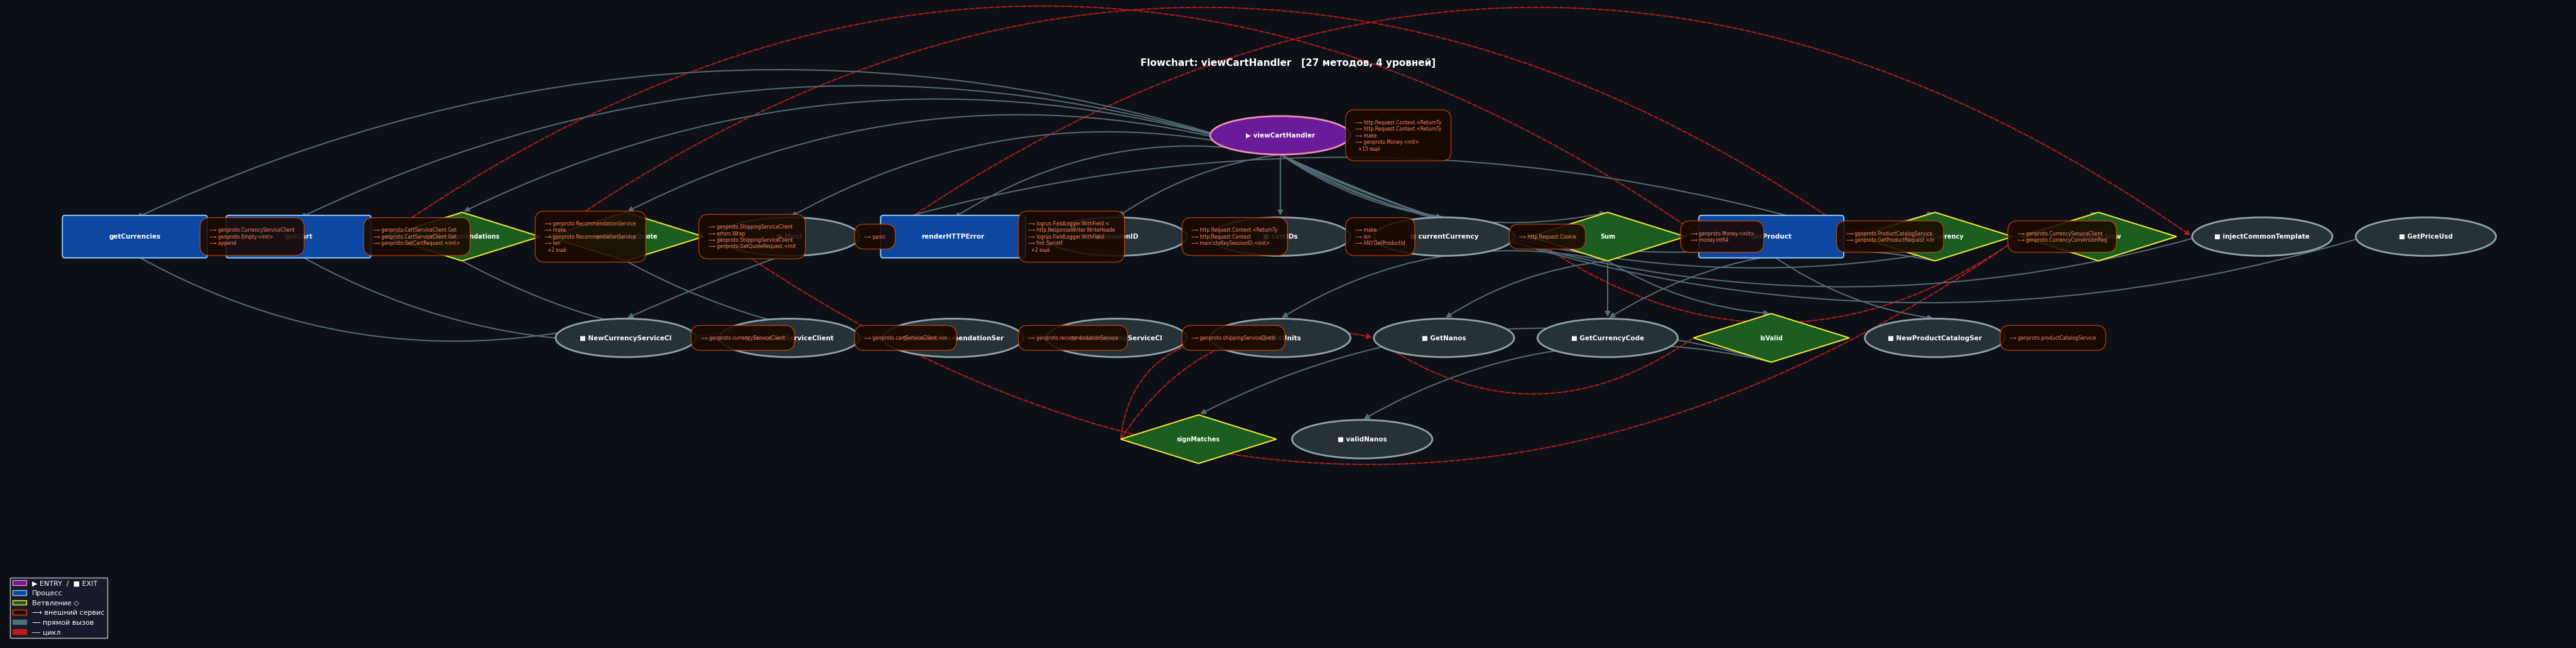

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import networkx as nx
from collections import deque, defaultdict


def visualize_flowchart_full(G, entry_id, ep_name, cg,
                              internal_methods, external_methods, exits,
                              save=True, show=True):

    reachable = set(nx.dfs_preorder_nodes(cg, entry_id))
    sub_cg    = cg.subgraph(reachable).copy()

    # ── BFS-уровни ────────────────────────────────────────────────────
    level_of = {entry_id: 0}
    queue    = deque([entry_id])
    while queue:
        node = queue.popleft()
        for child in sub_cg.successors(node):
            if child not in level_of:
                level_of[child] = level_of[node] + 1
                queue.append(child)

    levels    = defaultdict(list)
    for nid, lvl in level_of.items():
        levels[lvl].append(nid)
    n_levels  = max(levels.keys()) + 1
    max_width = max(len(v) for v in levels.values())

    # ── Параметры ─────────────────────────────────────────────────────
    BW, BH  = 180, 36
    DW, DH  = 200, 48
    OW, OH  = 180, 38
    X_GAP   = 210
    Y_GAP   = 100
    MX      = 60
    MY      = 60

    inner_W = MX * 2 + max_width * X_GAP
    H = MY * 2 + n_levels * Y_GAP + 40
    W = inner_W + 20

    fig, ax = plt.subplots(figsize=(max(14, W/80), max(10, H/72)))
    fig.patch.set_facecolor("#0d1117")
    ax.set_facecolor("#0d1117")
    ax.set_xlim(0, W); ax.set_ylim(H, 0)
    ax.set_title(
        f"Flowchart: {ep_name}   [{len(reachable)} методов, {n_levels} уровней]",
        fontsize=11, color="white", fontweight="bold", pad=10)
    ax.axis("off")

    # ── Цвета ─────────────────────────────────────────────────────────
    C_ENTRY    = "#6a1b9a"
    C_PROCESS  = "#0d47a1"
    C_DECISION = "#1b5e20"
    C_EXIT_C   = "#263238"
    C_EXTERNAL = "#e65100"
    C_TEXT     = "#ffffff"
    C_ARROW    = "#546e7a"
    C_ARROW_EX = "#ff7043"
    C_BACK     = "#b71c1c"

    # ── Позиции нод ───────────────────────────────────────────────────
    node_xy = {}
    for lvl in range(n_levels):
        nodes = levels[lvl]
        n     = len(nodes)
        total = (n - 1) * X_GAP
        x0    = inner_W / 2 - total / 2
        cy    = MY + lvl * Y_GAP
        for k, nid in enumerate(nodes):
            node_xy[nid] = (x0 + k * X_GAP, cy)

    # ── Размер ноды ───────────────────────────────────────────────────
    def node_size(nid):
        od = sub_cg.out_degree(nid) if nid in sub_cg else 0
        if nid == entry_id or nid in exits: return OW, OH
        if od > 1: return DW, DH
        return BW, BH

    def border_pt(nid, side):
        cx, cy = node_xy[nid]
        w, h   = node_size(nid)
        if side == "bottom": return cx, cy + h/2
        if side == "top":    return cx, cy - h/2
        if side == "left":   return cx - w/2, cy
        if side == "right":  return cx + w/2, cy
        return cx, cy

    # ── Фигуры ────────────────────────────────────────────────────────
    def draw_rect(cx, cy, w, h, color, label, border="#90caf9"):
        ax.add_patch(FancyBboxPatch(
            (cx-w/2, cy-h/2), w, h, boxstyle="round,pad=3",
            linewidth=1.4, edgecolor=border, facecolor=color, zorder=4))
        ax.text(cx, cy, label[:22], ha="center", va="center",
                fontsize=7.5, color=C_TEXT, fontweight="bold", zorder=5)

    def draw_diamond(cx, cy, w, h, color, label):
        hw, hh = w/2, h/2
        ax.add_patch(plt.Polygon(
            [(cx,cy-hh),(cx+hw,cy),(cx,cy+hh),(cx-hw,cy)],
            closed=True, linewidth=1.4,
            edgecolor="#ffeb3b", facecolor=color, zorder=4))
        ax.text(cx, cy, label[:20], ha="center", va="center",
                fontsize=7, color=C_TEXT, fontweight="bold", zorder=5)

    def draw_oval(cx, cy, w, h, color, label, border):
        ax.add_patch(mpatches.Ellipse(
            (cx, cy), w, h, linewidth=2.0,
            edgecolor=border, facecolor=color, zorder=4))
        ax.text(cx, cy, label[:22], ha="center", va="center",
                fontsize=7.5, color=C_TEXT, fontweight="bold", zorder=5)

    def draw_arrow(x1, y1, x2, y2, color=C_ARROW, rad=0.0, ls="-"):
        ax.annotate("", xy=(float(x2), float(y2)), xytext=(float(x1), float(y1)),
                    arrowprops=dict(arrowstyle="-|>", color=color,
                                   lw=1.4, mutation_scale=12, linestyle=ls,
                                   connectionstyle=f"arc3,rad={rad}"),
                    zorder=3)

    # ── Рёбра между методами ──────────────────────────────────────────
    for src, dst in sub_cg.edges():
        if src not in node_xy or dst not in node_xy: continue
        sl, dl = level_of.get(src,0), level_of.get(dst,0)
        if dl > sl:
            x1,y1 = border_pt(src,"bottom")
            x2,y2 = border_pt(dst,"top")
            dx = abs(node_xy[src][0] - node_xy[dst][0])
            draw_arrow(x1,y1,x2,y2, C_ARROW,
                       rad=0.0 if dx < 15 else (0.12 if dx < 300 else 0.2))
        else:
            x1,y1 = border_pt(src,"left")
            x2,y2 = border_pt(dst,"left")
            draw_arrow(x1,y1,x2,y2, C_BACK, rad=-0.35, ls="--")

    # ── Ноды ──────────────────────────────────────────────────────────
    for nid, (cx, cy) in node_xy.items():
        name   = internal_methods[nid].get("NAME","").strip('"')
        od     = sub_cg.out_degree(nid) if nid in sub_cg else 0
        is_en  = (nid == entry_id)
        is_ex  = (nid in exits)

        if is_en:
            draw_oval(cx, cy, OW, OH, C_ENTRY, f"▶ {name}", "#f48fb1")
        elif is_ex:
            draw_oval(cx, cy, OW, OH, C_EXIT_C, f"■ {name}", "#90a4ae")
        elif od > 1:
            draw_diamond(cx, cy, DW, DH, C_DECISION, name)
        else:
            draw_rect(cx, cy, BW, BH, C_PROCESS, name)

        # Внешние вызовы — компактный список ПОД нодой слева
        ext_calls = get_external_calls_for_method(G, nid, external_methods)
        if ext_calls:
            w, h = node_size(nid)
            # Маленький значок + текст рядом с нодой
            tag_lines = []
            for ec in ext_calls[:4]:
                short = ec["full_name"].split("/")[-1][:30]
                tag_lines.append(f"⟶ {short}")
            if len(ext_calls) > 4:
                tag_lines.append(f"  +{len(ext_calls)-4} ещё")

            tag_text = "\n".join(tag_lines)
            ax.text(cx + w/2 + 6, cy,
                    tag_text,
                    ha="left", va="center",
                    fontsize=5.5, color="#ff8a65",
                    zorder=6,
                    bbox=dict(boxstyle="round,pad=2",
                              fc="#1a0800", ec="#e65100",
                              alpha=0.88, linewidth=0.8))

    # ── Горизонтальные направляющие ───────────────────────────────────
    for lvl in range(n_levels):
        cy = MY + lvl * Y_GAP
        ax.axhline(cy, color="#ffffff", lw=0.15, alpha=0.07, zorder=1)

    # ── Легенда ───────────────────────────────────────────────────────
    ax.legend(handles=[
        mpatches.Patch(facecolor=C_ENTRY,    edgecolor="#f48fb1", label="▶ ENTRY  /  ■ EXIT"),
        mpatches.Patch(facecolor=C_PROCESS,  edgecolor="#90caf9", label="Процесс"),
        mpatches.Patch(facecolor=C_DECISION, edgecolor="#ffeb3b", label="Ветвление ◇"),
        mpatches.Patch(facecolor="#1a0800",  edgecolor="#e65100", label="⟶ внешний сервис"),
        mpatches.Patch(color=C_ARROW,  label="── прямой вызов"),
        mpatches.Patch(color=C_BACK,   label="╌╌ цикл"),
    ], fontsize=8, loc="lower left",
       facecolor="#1a1a2e", labelcolor="white", framealpha=0.95)

    plt.tight_layout()
    if save:
        safe  = ep_name.replace("/","_").replace(" ","_").replace(".","_")
        fname = f"flowchart_{safe}.png"
        plt.savefig(fname, dpi=150, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        print(f"  ✓ {fname}")
    if show:
        plt.show()
    else:
        plt.close()


# ── Вызов ─────────────────────────────────────────────────────────────────
IDX = 3
nid, ep = handlers[IDX]
visualize_flowchart_full(G, nid, ep["name"], cg,
                          internal_methods, external_methods, exits)

In [60]:
from cpg import EndpointDetector, print_endpoints

detector  = EndpointDetector(G)   # no package_root needed
endpoints = detector.detect()
print(endpoints)
print_endpoints(endpoints)

[Endpoint(node_id='107374182770', name='viewCartHandler', full_name='main.frontendServer.viewCartHandler', filename='handlers.go', in_degree=0, out_degree=15, callees=['GetPriceUsd', 'MultiplySlow', 'Must', 'Sum', 'cartIDs', 'convertCurrency', 'currentCurrency', 'getCart', 'getCurrencies', 'getProduct', 'getRecommendations', 'getShippingQuote', 'injectCommonTemplateData', 'renderHTTPError', 'sessionID']), Endpoint(node_id='107374182767', name='productHandler', full_name='main.frontendServer.productHandler', filename='handlers.go', in_degree=0, out_degree=12, callees=['GetPriceUsd', 'convertCurrency', 'currentCurrency', 'getCart', 'getCurrencies', 'getProduct', 'getRecommendations', 'httpGetPackagingInfo', 'injectCommonTemplateData', 'isPackagingServiceConfigured', 'renderHTTPError', 'sessionID']), Endpoint(node_id='107374182771', name='placeOrderHandler', full_name='main.frontendServer.placeOrderHandler', filename='handlers.go', in_degree=0, out_degree=12, callees=['MultiplySlow', 'Mus

In [62]:
from cpg import MethodConstructor, print_method_graph, PseudocodeGenerator

mc = MethodConstructor(G)
mg = mc.build("107374182770")   # chooseAd

print_method_graph(mg)


══════════════════════════════════════════════════════════════════════
  METHOD  viewCartHandler
  main.frontendServer.viewCartHandler
  handlers.go  lines 251–318
  Signature: main.frontendServer.viewCartHandler(net/http.ResponseWriter, *net/http.Request)
──────────────────────────────────────────────────────────────────────

  PARAMETERS (3)
    [0] fe: main.frontendServer  (BY_SHARING)
    [1] w: net/http.ResponseWriter  (BY_VALUE)
    [2] r: *net/http.Request  (BY_SHARING)

  RETURN TYPE
    void  (BY_VALUE)

  LOCAL VARS (13)
    L 252  log: net/http.Request.Context.<ReturnType>.<unknown>.Value.<ReturnType>.<unknown>
    L 254  currencies: []string
    L 259  cart: []*github.com/GoogleCloudPlatform/microservices-demo/src/frontend/genproto.CartItem
    L 266  recommendations: []*github.com/GoogleCloudPlatform/microservices-demo/src/frontend/genproto.Product
    L 271  shippingCost: *github.com/GoogleCloudPlatform/microservices-demo/src/frontend/genproto.Money
    L 282  items: map

In [65]:
# get + print
pg   = PseudocodeGenerator()    # no G needed
algo = pg.print_algo(mg)        # → Dict[int, SourceLine] + prints to stdout


────────────────────────────────────────────────────────────────────────
  Algorithm : viewCartHandler
  File      : handlers.go  lines 251–318
────────────────────────────────────────────────────────────────────────
  FUNCTION viewCartHandler(fe: main.frontendServer, w: net/http.ResponseWriter, r: *net/http.Request):
    log := r.Context().Value(ctxKeyLog{}).(logrus.FieldLogger)
    log.Debug(\"view user cart\")
    currencies, err := fe.getCurrencies(r.Context())
    if err != nil:
      renderHTTPError(log, r, w, errors.Wrap(err, \"could not retrieve currencies\"),
      return
      cart, err := fe.getCart(r.Context(), sessionID(r))
    if err != nil:
        renderHTTPError(log, r, w, errors.Wrap(err, \"could not retrieve cart\"), http.S
        return
        recommendations, err := fe.getRecommendations(r.Context(), sessionID(r), cartIDs
    if err != nil:
          log.WithField(\"error\", err).Warn(\"failed to get product recommendations\")
        shippingCost, err := fe.get

In [ ]:
from cpg import EndpointFlow, print_endpoint_flow

flow   = EndpointFlow(G, max_depth=10)
result = flow.build("107374182770")   # your METHOD node_id

print_endpoint_flow(result, show_cfg=False)


════════════════════════════════════════════════════════════════════════
  ENDPOINT FLOW  viewCartHandler
  main.frontendServer.viewCartHandler
  Total invocations : 113
────────────────────────────────────────────────────────────────────────
  [  0] viewCartHandler
        full : main.frontendServer.viewCartHandler
        cfg  : 259 nodes  (dfs-approx)
            0 L 251  METHOD_PARAMETER_IN  r *http.Request
            1 L 259  LOCAL               cart
            2 L 282  LOCAL               items
            3 L 306  CONTROL_STRUCTURE   if err != nil
            4 L 279  MEMBER              Quantity
            5 L 291  CONTROL_STRUCTURE   if err != nil
            6 L 255  BLOCK               <empty>
            7 L 267  CONTROL_STRUCTURE   if err != nil
            8 L 272  BLOCK               <empty>
            9 L 286  BLOCK               <empty>

  [  1]   getCurrencies
          full : main.frontendServer.getCurrencies
          cfg  : 57 nodes  (dfs-approx)
             